In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import transforms
from torchvision import datasets
from torch.utils.data.sampler import SubsetRandomSampler

from models.resnet import ResNet
from data_loader import get_data_loaders, plot_images

## Data Augmentation, Preprocess (Normalization)

In [3]:
# data directory
data_dir = 'data/cifar10'
batch_size = 128

In [4]:
# =======================================================================================
# DATA LOADING (Before Augementation For Visualizing Purpose)
# =======================================================================================
train_transform = transforms.Compose([
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

# ---Load data---
train_loader, test_loader = get_data_loaders(data_dir,
                                             batch_size,
                                             train_transform,
                                             test_transform,
                                             shuffle=True,
                                             num_workers=4,
                                             pin_memory=True)

/mnt/d/DUY/LUH/Hiwi_TNT/Tasks/Cifar/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


/mnt/d/DUY/LUH/Hiwi_TNT/Tasks/Cifar/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
/mnt/d/DUY/LUH/Hiwi_TNT/Tasks/Cifar/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


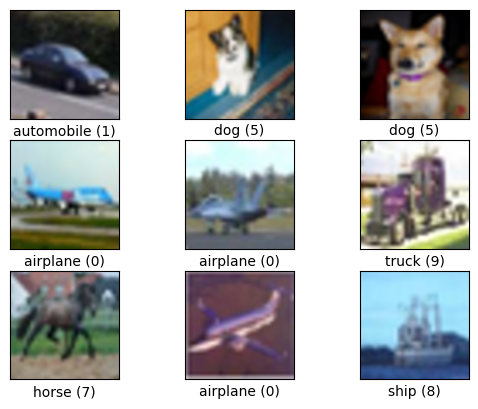

torch.Size([128, 3, 32, 32])


In [5]:
# ---Visualize---
# Training images
data_iter = iter(train_loader)
images, labels = next(data_iter)
X = images.numpy().transpose([0, 2, 3, 1])
plot_images(X, labels)
print(images.shape)

In [6]:
# =======================================================================================
# DATA AUGMENTATION AND NORMALIZATION
# =======================================================================================

# Normalization variable
# The normalization values are calculated from the training set and are used to normalize both the training and testing sets.
# They have been pre_computed publicly and are commonly used for the CIFAR-10 dataset in practice.
normalize = transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],   
                                 std=[0.2023, 0.1994, 0.2010])

# Training Set
train_transform = transforms.Compose([
    transforms.Pad(4),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(32),
    transforms.ToTensor(),
    normalize
])

# Testing Set
test_transform = transforms.Compose([
    transforms.ToTensor(),
    normalize
])

In [7]:
# ---Reload data with augmentation---
train_loader, test_loader = get_data_loaders(data_dir,
                                             batch_size,
                                             train_transform,
                                             test_transform,
                                             shuffle=True,
                                             num_workers=4,
                                             pin_memory=True)

/mnt/d/DUY/LUH/Hiwi_TNT/Tasks/Cifar/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.16412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.3411214].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5000975].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].
Clipping input data to

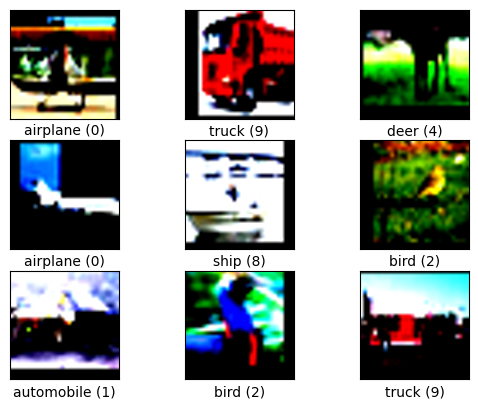

torch.Size([128, 3, 32, 32])


In [8]:
# Training set
data_iter = iter(train_loader)
images, labels = next(data_iter)
X = images.numpy().transpose([0, 2, 3, 1])
plot_images(X, labels)
print(images.shape)

/mnt/d/DUY/LUH/Hiwi_TNT/Tasks/Cifar/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.2464638].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2412531..2.7537313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9677593..2.7537313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2546015..2.6366696].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3592544..2.7537313].
Clipping input data 

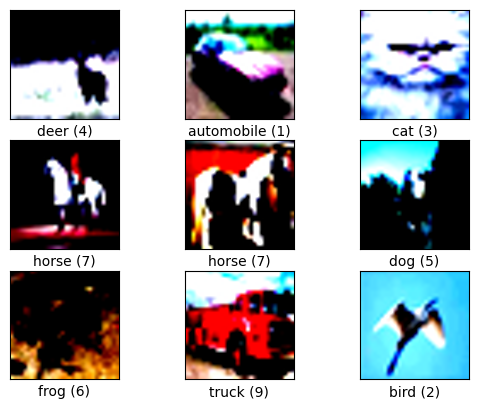

torch.Size([128, 3, 32, 32])


In [9]:
# Testing set
data_iter = iter(test_loader)
images, labels = next(data_iter)
X = images.numpy().transpose([0, 2, 3, 1])
plot_images(X, labels)
print(images.shape)

## Training

## Evaluating

## Plotting
